# Emisiones de Gases de Efecto Invernadero de Argentina (1990–2022)

El inventario nacional reúne las emisiones y absorciones anuales de gases de efecto invernadero de Argentina, y detrás de cada total hay sectores, actividades y gases que pesan de manera muy distinta. Este notebook recorre ese inventario con una pregunta: **¿cómo evolucionaron las emisiones entre 1990 y 2022, y qué sectores y actividades explican los principales cambios?**

Empezamos conociendo y limpiando los datos, después vemos cómo se reparten por sector, actividad y gas, y cerramos con las principales fuentes de los últimos años y las conclusiones. La limpieza que hacemos acá es la base del modelo SQL (notebook 02) y del dashboard de Power BI.

Para ordenar el recorrido, buscamos respuesta a cinco preguntas:

1. ¿Cómo evolucionó el balance total de emisiones y remociones?
2. ¿Qué sectores y actividades pesan más, y cuáles cambiaron más entre 1990 y 2022?
3. ¿Qué gases dominan y cómo cambió su composición?
4. ¿Cuáles son las principales fuentes en los últimos años?
5. ¿Qué implica todo esto desde la gestión ambiental?

**Fuente:** Subsecretaría de Ambiente, *Emisiones de gases de efecto invernadero*, recurso "Inventario de GEI – Datos totales. Periodo 1990-2022", en [datos.gob.ar](https://datos.gob.ar/dataset/emisiones-de-gases-de-efecto-invernadero/resource/21116ef2-0a55-5e43-a761-99bd45594b57). Licencia Creative Commons Attribution 4.0.

## 1. Carga de los datos

### 1.1 Librerías y rutas

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from textwrap import fill

# La raíz del proyecto se busca hacia arriba desde la carpeta de trabajo, así el notebook
# funciona se abra Jupyter donde se abra (raíz, notebook/ o una carpeta que contenga el proyecto)
def encontrar_raiz(archivo=("data", "raw", "emisiones_datos_totales_1990_2022.csv")):
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        for candidata in (base, base / "emisiones-gei-argentina"):
            if candidata.joinpath(*archivo).exists():
                return candidata
    raise FileNotFoundError("No se encontró data/raw/" + archivo[-1] + " desde " + str(cwd))

ROOT = encontrar_raiz()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

VALOR = "valor_en_toneladas_de_co2e"

Las rutas se calculan a partir de la ubicación del notebook, así que el proyecto corre igual en cualquier computadora, siempre que se abra desde la carpeta `notebook/`.

### 1.2 Lectura del archivo

In [2]:
df = pd.read_csv(RAW / "emisiones_datos_totales_1990_2022.csv", sep=";")

## 2. Primera mirada al dataset

### 2.1 Dimensiones, columnas y tipos

In [3]:
print(f"Filas y columnas: {df.shape}\n")
df.info()
display(df.head(3))
display(df.tail(3))

Filas y columnas: (7778, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7778 entries, 0 to 7777
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   año                         7778 non-null   int64  
 1   sector                      7778 non-null   object 
 2   actividad                   7778 non-null   object 
 3   subactividad                7778 non-null   object 
 4   categoria                   7778 non-null   object 
 5   id_ipcc                     7778 non-null   object 
 6   tipo_de_gas                 7778 non-null   object 
 7   valor_en_toneladas_de_co2e  7778 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 486.3+ KB


,año,sector,actividad,subactividad,categoria,id_ipcc,tipo_de_gas,valor_en_toneladas_de_co2e
0,1990,Energía,Actividades de quema de combustible,Industrias de la energía,Producción pública de electricidad y calor,1A1a,CO2,15.33
1,1991,Energía,Actividades de quema de combustible,Industrias de la energía,Producción pública de electricidad y calor,1A1a,CO2,18.78
2,1992,Energía,Actividades de quema de combustible,Industrias de la energía,Producción pública de electricidad y calor,1A1a,CO2,17.54


,año,sector,actividad,subactividad,categoria,id_ipcc,tipo_de_gas,valor_en_toneladas_de_co2e
7775,2020,Residuos,Aguas Residuales,Aguas residuales Industriales,Aguas residuales Industriales: Alimentos y Beb...,5D2e,CH4,0.76
7776,2021,Residuos,Aguas Residuales,Aguas residuales Industriales,Aguas residuales Industriales: Alimentos y Beb...,5D2e,CH4,0.80
7777,2022,Residuos,Aguas Residuales,Aguas residuales Industriales,Aguas residuales Industriales: Alimentos y Beb...,5D2e,CH4,0.84


El archivo tiene 7.778 filas y 8 columnas, y ninguna columna tiene valores nulos. Cada fila describe una fuente de emisión en un año, con su gas y su valor.

### 2.2 Cómo está organizada la información

In [4]:
df[["sector", "actividad", "subactividad", "categoria", "id_ipcc", "tipo_de_gas"]].nunique()

sector            4
actividad        12
subactividad     32
categoria        68
id_ipcc         162
tipo_de_gas       5
dtype: int64

In [5]:
df.groupby(["sector", "actividad"]).size()

sector                                                           actividad                                                          
Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra   Ganadería                                                               924
                                                                 Tierra                                                                  330
                                                                 Uso de Suelos                                                          1980
Energía                                                          Actividades de quema de combustible                                    2146
                                                                 Emisiones fugitivas provenientes de la fabricación de combustibles      924
Procesos industriales y uso de productos                         Industria de los metales                                                264
                     

La información tiene forma de jerarquía: 4 sectores, que se abren en 12 actividades, 32 subactividades y 68 categorías, más el código IPCC de cada fuente y 5 tipos de gas. Cada actividad pertenece a un único sector, así que la clasificación es coherente.

In [6]:
pd.crosstab(df["sector"], df["tipo_de_gas"])

tipo_de_gas,CH4,CO2,HFC,N2O,PFC
sector,,,,,
"Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra",858,363,0,2013,0
Energía,1179,1075,0,816,0
Procesos industriales y uso de productos,198,579,234,33,66
Residuos,281,33,0,50,0


Esta tabla cuenta registros, no emisiones, pero ya anticipa el perfil de cada sector: Agricultura concentra los registros de N₂O, Energía tiene muchos de CH₄ y CO₂, Residuos es sobre todo CH₄, y los HFC y PFC aparecen solo en Procesos industriales.

### 2.3 Registros por año

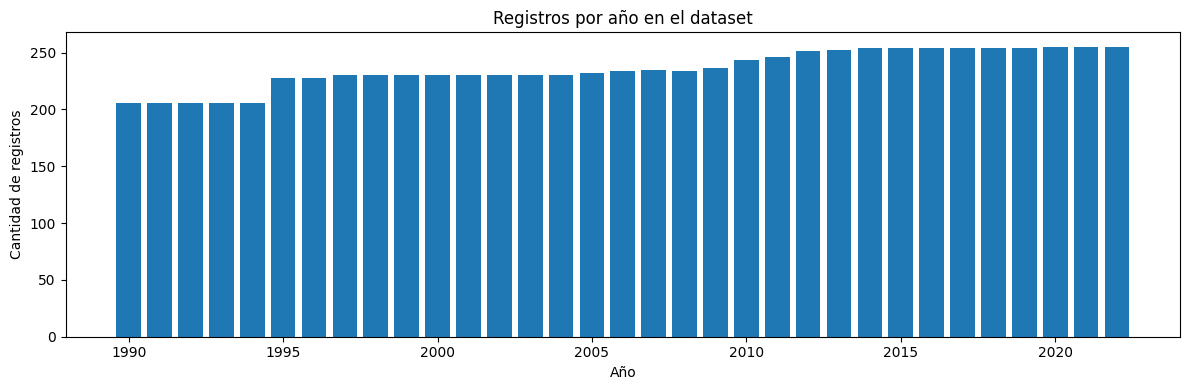

In [7]:
registros_por_año = df["año"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(registros_por_año.index, registros_por_año.values)
plt.xlabel("Año")
plt.ylabel("Cantidad de registros")
plt.title("Registros por año en el dataset")
plt.tight_layout()
plt.show()

In [8]:
inicio = df.groupby(["id_ipcc", "tipo_de_gas"])["año"].min()

print(f"Combinaciones código IPCC–gas: {len(inicio)}")
print(f"Las que empiezan a informarse después de 1990: {(inicio > 1990).sum()}")
inicio[inicio > 1990].value_counts().sort_index()

Combinaciones código IPCC–gas: 242
Las que empiezan a informarse después de 1990: 37


año
1995    22
1997     2
2005     2
2006     2
2010     6
2011     1
2012     2
Name: count, dtype: int64

**Hallazgo:** la cantidad de registros por año no es constante. Pasa de 206 en 1990 a 255 en 2022. La explicación está en los datos: de las 242 combinaciones código IPCC–gas, 37 empiezan a informarse después de 1990 (22 en 1995, 2 en 1997, 2 en 2005, 2 en 2006, 6 en 2010, 1 en 2011, 2 en 2012).

El inventario, entonces, fue incorporando detalle con los años. El archivo no aclara si se trata de fuentes nuevas o de un mayor nivel de desagregación, algo para tener presente cuando comparemos 1990 con 2022.

### 2.4 La magnitud de los valores

In [9]:
df[VALOR].describe()

count    7778.000000
mean        1.594045
std         7.512023
min       -43.740000
25%         0.000000
50%         0.050000
75%         0.550000
max        77.930000
Name: valor_en_toneladas_de_co2e, dtype: float64

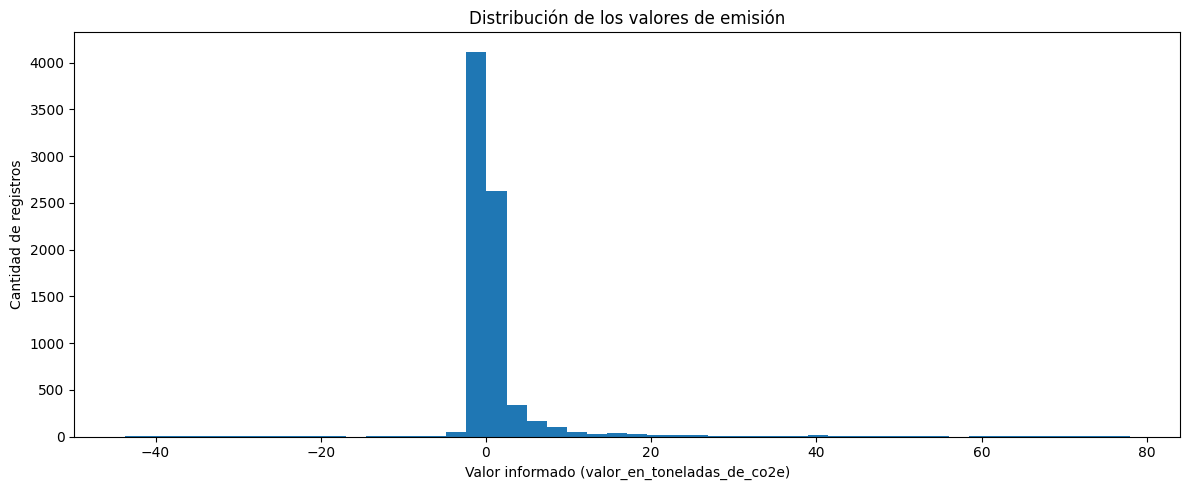

In [10]:
plt.figure(figsize=(12, 5))
plt.hist(df[VALOR], bins=50)
plt.xlabel(f"Valor informado ({VALOR})")
plt.ylabel("Cantidad de registros")
plt.title("Distribución de los valores de emisión")
plt.tight_layout()
plt.show()

La distribución es muy asimétrica: la mitad de los registros vale 0,05 o menos y tres de cada cuatro no pasan de 0,55, pero el máximo llega a 77,93. Son muchas fuentes chicas y pocas muy grandes, algo esperable en un inventario. También hay valores negativos (el mínimo es −43,74), de los que nos ocupamos en la sección 3.3.

**Sobre las unidades:** la columna se llama `valor_en_toneladas_de_co2e`, pero ese nombre no coincide con las magnitudes: más adelante vamos a ver que el balance de un año va de unas 274 a unas 450 unidades, y un inventario nacional con ese orden de magnitud solo tiene sentido si los valores están en **millones de toneladas de CO₂ equivalente**. Por eso en los gráficos y textos usamos **MtCO₂e**.

## 3. Limpieza

### 3.1 Normalización del texto

In [11]:
columnas_texto = ["sector", "actividad", "subactividad", "categoria", "id_ipcc", "tipo_de_gas"]

for columna in columnas_texto:
    con_espacios = (df[columna] != df[columna].str.strip()).sum()
    print(f"{columna}: {con_espacios} valores con espacios al principio o al final")

sector: 3234 valores con espacios al principio o al final
actividad: 4225 valores con espacios al principio o al final
subactividad: 4060 valores con espacios al principio o al final
categoria: 766 valores con espacios al principio o al final
id_ipcc: 0 valores con espacios al principio o al final
tipo_de_gas: 0 valores con espacios al principio o al final


Varias columnas de texto traen espacios sobrantes, y eso haría que una misma categoría se leyera como dos al agrupar. Los quitamos ahora, antes de buscar duplicados, para que dos filas iguales salvo por un espacio no pasen desapercibidas.

In [12]:
for columna in columnas_texto:
    df[columna] = df[columna].str.strip()

# Comprobamos que no quedaron textos vacíos
print("Textos vacíos:", (df[columnas_texto] == "").sum().sum())

Textos vacíos: 0


### 3.2 Registros duplicados

In [13]:
columnas_clave = ["año", "sector", "actividad", "subactividad", "categoria", "id_ipcc", "tipo_de_gas"]

print("Filas con las mismas etiquetas que otra:", df.duplicated(subset=columnas_clave).sum())
print("Filas idénticas a otra, valor incluido:", df.duplicated().sum())

grupos = df.groupby(columnas_clave)[VALOR].agg(filas="size", valores_distintos="nunique").query("filas > 1")
print(f"\nGrupos con etiquetas repetidas: {len(grupos)}")
print(f"De ellos, con valores distintos: {(grupos['valores_distintos'] > 1).sum()}")

Filas con las mismas etiquetas que otra: 168
Filas idénticas a otra, valor incluido: 41

Grupos con etiquetas repetidas: 98
De ellos, con valores distintos: 83


Hay que distinguir dos cosas. Por un lado, 168 filas repiten las etiquetas de otra (año, sector, actividad, subactividad, categoría, código y gas). Por el otro, solo 41 repiten además el valor.

Las etiquetas repetidas no alcanzan para hablar de duplicados: forman 98 grupos y en 83 de ellos los valores son distintos, así que esas filas las conservamos. Las 41 filas idénticas en todo sí las miramos de cerca.

In [14]:
exactas = df[df.duplicated(keep=False)]

# ¿Dónde están?
display(exactas.groupby(["sector", "categoria"]).size())

# ¿Cuántas veces se repite cada fila?
display(exactas.groupby(columnas_clave + [VALOR]).size().value_counts())

# Un año de ejemplo de esa categoría: misma etiqueta, valores distintos
df[(df["id_ipcc"] == "2F1f") & (df["año"] == 2022)][["categoria", "id_ipcc", "tipo_de_gas", VALOR]]

sector                                                          categoria                                   
Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra  Otras Ganaderías                                 4
Procesos industriales y uso de productos                        Usos de productos como sustitutos de las SAO    68
dtype: int64

2    21
3    10
Name: count, dtype: int64

,categoria,id_ipcc,tipo_de_gas,valor_en_toneladas_de_co2e
4078,Usos de productos como sustitutos de las SAO,2F1f,HFC,0.00
4079,Usos de productos como sustitutos de las SAO,2F1f,HFC,0.41
4080,Usos de productos como sustitutos de las SAO,2F1f,HFC,2.56
4081,Usos de productos como sustitutos de las SAO,2F1f,HFC,0.81
4082,Usos de productos como sustitutos de las SAO,2F1f,HFC,0.62
4083,Usos de productos como sustitutos de las SAO,2F1f,HFC,0.00


Las filas involucradas son 72, repartidas en 31 grupos (21 de dos filas iguales y 10 de tres). Casi todas (68 de 72) pertenecen a "Usos de productos como sustitutos de las SAO", con HFC, y el resto a "Excretas en pasturas". Sus valores van de 0,00 a 0,02.

Dentro de esa categoría hay varias filas con la misma etiqueta y valores distintos en un mismo año, lo que sugiere que el archivo agrupa varios compuestos bajo un solo rótulo: que dos de ellos coincidan en un valor redondeado a dos decimales sería esperable. Aun así, decidimos eliminar las copias exactas, porque en este nivel de detalle una repetición inflaría los totales. El costo de equivocarnos es mínimo: las 41 filas que se eliminan suman 0,15 sobre un total de 12.398,33 MtCO₂e.

In [15]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Filas y columnas tras eliminar duplicados exactos: {df.shape}")

Filas y columnas tras eliminar duplicados exactos: (7737, 8)


Quedan 7.737 registros.

### 3.3 Emisiones y remociones

In [16]:
negativos = (df[VALOR] < 0).sum()
ceros = (df[VALOR] == 0).sum()
positivos = (df[VALOR] > 0).sum()

print(f"Valores positivos: {positivos} --> Emisión de GEI")
print(f"Valores cero: {ceros} --> Sin emisión ni remoción informada")
print(f"Valores negativos: {negativos} --> Remoción de CO₂")

Valores positivos: 5644 --> Emisión de GEI
Valores cero: 1949 --> Sin emisión ni remoción informada
Valores negativos: 144 --> Remoción de CO₂


El 72,9 % de los registros son emisiones (5.644), el 25,2 % son ceros (1.949) y el 1,9 % son valores negativos (144). Los ceros son valores informados, no faltantes, así que los dejamos. Los negativos merecen una pregunta: ¿son errores o tienen sentido?

In [17]:
remociones = df[df[VALOR] < 0]

print("Gases:", remociones["tipo_de_gas"].unique().tolist())
print("Actividades:", remociones["actividad"].unique().tolist())
remociones["categoria"].value_counts()

Gases: ['CO2']
Actividades: ['Tierra']


categoria
Tierras forestales que permanecen como tales    66
Pastizales convertidos en Tierras de Cultivo    33
Productos de madera recolectada                 33
Tierras de cultivo que permanecen como tales    12
Name: count, dtype: int64

Los 144 valores negativos son todos CO₂ de la actividad "Tierra", y se concentran en cuatro categorías: tierras forestales que permanecen como tales (66), pastizales convertidos en tierras de cultivo (33), productos de madera recolectada (33) y tierras de cultivo que permanecen como tales (12). En un inventario de gases de efecto invernadero, un valor negativo de CO₂ representa carbono que se retira de la atmósfera, así que **no son errores y no los eliminamos**.

Para poder separarlos después, creamos la variable `tipo_de_registro`, que distingue emisiones, remociones y registros sin emisión ni remoción.

In [18]:
condiciones = [df[VALOR] > 0, df[VALOR] < 0, df[VALOR] == 0]
categorias = ["Emisión", "Remoción", "Sin emisión/remoción"]

df["tipo_de_registro"] = np.select(condiciones, categorias, default="Sin clasificar")
df["tipo_de_registro"].value_counts()

tipo_de_registro
Emisión                 5644
Sin emisión/remoción    1949
Remoción                 144
Name: count, dtype: int64

## 4. Evolución y sectores

Hasta acá contamos registros. De ahora en adelante sumamos los **valores** de `valor_en_toneladas_de_co2e`, expresados en MtCO₂e. Cuando hablamos de *balance* nos referimos a la suma de emisiones y remociones, y por *emisiones brutas* a la suma de los valores positivos.

### 4.1 Evolución anual del balance

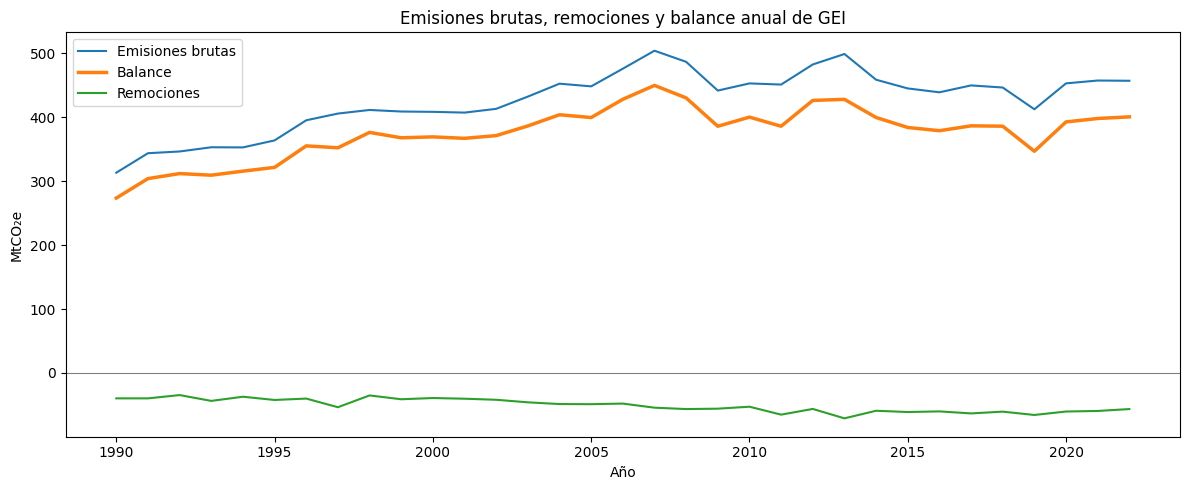

,emisiones_brutas,remociones,balance
año,,,
1990,313.4,-39.7,273.7
2007,504.3,-54.3,450.0
2022,457.2,-56.5,400.8


In [19]:
emisiones_brutas = df[df[VALOR] > 0].groupby("año")[VALOR].sum()
remociones = df[df[VALOR] < 0].groupby("año")[VALOR].sum()
balance = df.groupby("año")[VALOR].sum()

evolucion = pd.DataFrame({
    "emisiones_brutas": emisiones_brutas,
    "remociones": remociones,
    "balance": balance,
})

plt.figure(figsize=(12, 5))
plt.plot(evolucion.index, evolucion["emisiones_brutas"], label="Emisiones brutas")
plt.plot(evolucion.index, evolucion["balance"], label="Balance", linewidth=2.5)
plt.plot(evolucion.index, evolucion["remociones"], label="Remociones")
plt.axhline(0, color="gray", linewidth=0.8)
plt.xlabel("Año")
plt.ylabel("MtCO₂e")
plt.title("Emisiones brutas, remociones y balance anual de GEI")
plt.legend()
plt.tight_layout()
plt.show()

evolucion.loc[[1990, 2007, 2022]].round(1)

El balance pasa de 273,7 MtCO₂e en 1990 a 400,8 en 2022, un aumento del 46 %. No fue un camino parejo: sube hasta un máximo de 450,0 en 2007 y desde 2009 oscila entre 347,0 (2019) y 428,2 (2013), sin volver a ese pico. En 2022 queda un 11 % por debajo del máximo.

Las emisiones brutas pasan de 313,4 a 457,2 y las remociones de −39,7 a −56,5, con su mayor magnitud en 2013 (−71,0). Las remociones amortiguaron el aumento, pero no alcanzaron para frenarlo.

### 4.2 Qué sectores pesan más

,balance_1990_2022,participacion_%
sector,,
"Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra",5899.92,47.6
Energía,5422.41,43.7
Residuos,576.18,4.6
Procesos industriales y uso de productos,499.82,4.0


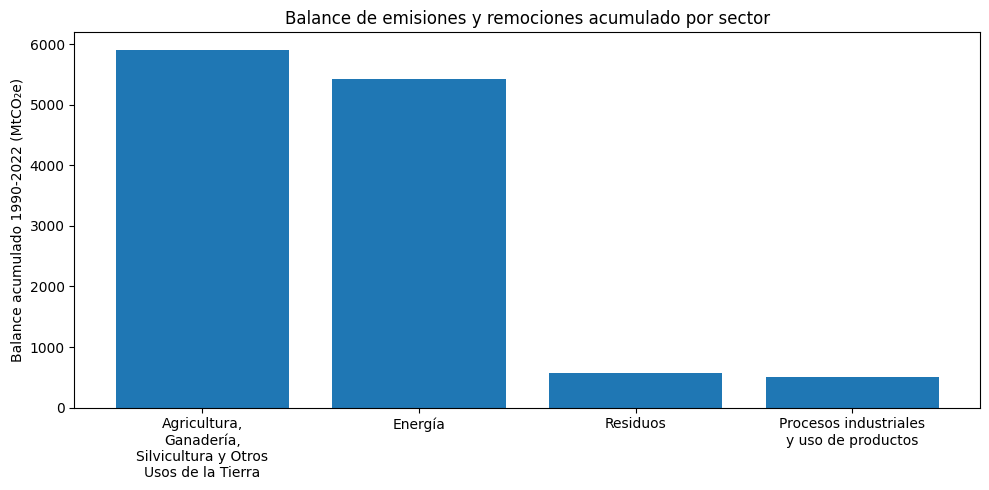

In [20]:
totales_por_sector = df.groupby("sector")[VALOR].sum().sort_values(ascending=False)
participacion_sector = (totales_por_sector / totales_por_sector.sum() * 100).round(1)

display(pd.concat([totales_por_sector.round(2).rename("balance_1990_2022"),
                   participacion_sector.rename("participacion_%")], axis=1))

plt.figure(figsize=(10, 5))
plt.bar([fill(s, 22) for s in totales_por_sector.index], totales_por_sector.values)
plt.ylabel("Balance acumulado 1990-2022 (MtCO₂e)")
plt.title("Balance de emisiones y remociones acumulado por sector")
plt.tight_layout()
plt.show()

Dos sectores concentran casi todo el balance acumulado: "Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra" (5.900 MtCO₂e, 47,6 %) y "Energía" (5.422, 43,7 %). Bastante más atrás quedan "Residuos" (4,6 %) y "Procesos industriales y uso de productos" (4,0 %).

### 4.3 Cómo evolucionó cada sector

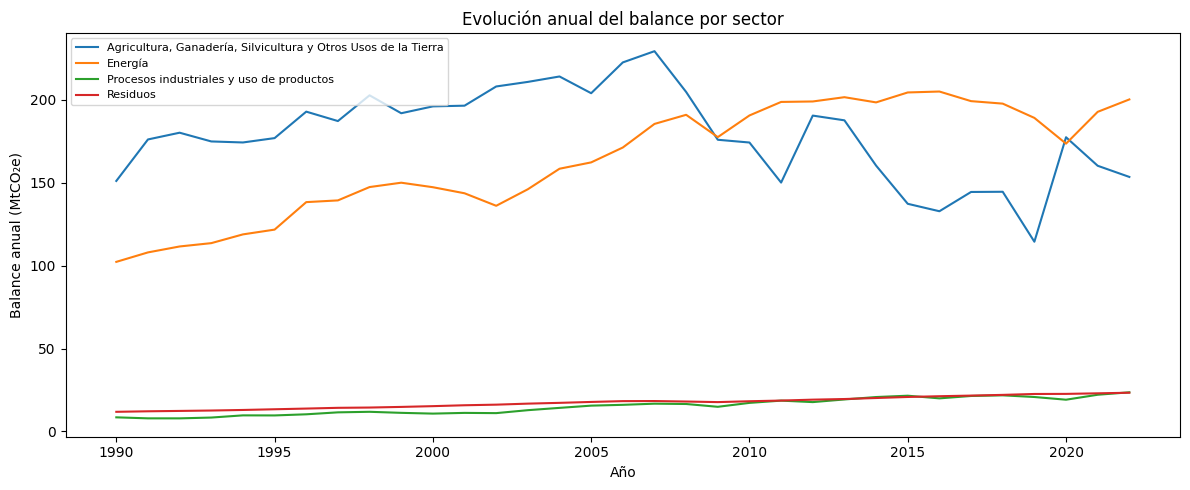

In [21]:
pivot_sector_año = df.pivot_table(index="año", columns="sector", values=VALOR, aggfunc="sum")

plt.figure(figsize=(12, 5))
for sector in pivot_sector_año.columns:
    plt.plot(pivot_sector_año.index, pivot_sector_año[sector], label=sector)
plt.xlabel("Año")
plt.ylabel("Balance anual (MtCO₂e)")
plt.title("Evolución anual del balance por sector")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [22]:
# Comparación entre puntas: 1990 contra 2022
variacion_absoluta = pivot_sector_año.loc[2022] - pivot_sector_año.loc[1990]
variacion_pct = variacion_absoluta / pivot_sector_año.loc[1990].abs() * 100

variacion = pd.concat([variacion_absoluta.rename("variacion_MtCO2e"),
                       variacion_pct.rename("variacion_%")], axis=1)
display(variacion.sort_values("variacion_MtCO2e", ascending=False).round(1))

# Participación de cada sector en el balance de algunos años
participacion = pivot_sector_año.div(pivot_sector_año.sum(axis=1), axis=0) * 100
participacion.loc[[1990, 2007, 2022]].round(1)

,variacion_MtCO2e,variacion_%
sector,,
Energía,98.0,95.8
Procesos industriales y uso de productos,15.1,178.2
Residuos,11.5,97.5
"Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra",2.4,1.6


sector,"Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra",Energía,Procesos industriales y uso de productos,Residuos
año,,,,
1990,55.2,37.4,3.1,4.3
2007,51.0,41.2,3.7,4.1
2022,38.3,50.0,5.9,5.8


**Energía** es el sector que más creció: de 102,3 a 200,3 MtCO₂e entre 1990 y 2022 (+98,0, un 96 % más), con un máximo de 205,1 en 2016. Su participación en el balance pasó de 37,4 % a 50,0 %.

**Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra** cuenta otra historia. Entre las puntas casi no cambió (de 151,1 a 153,6), pero comparar solo dos años esconde lo que pasó en el medio: llegó a 229,4 en 2007 y después bajó. Ese pico se explica sobre todo por la actividad "Tierra", que pasó de 44,3 en 1990 a 117,3 en 2007 y volvió a 47,0 en 2022. Su participación en el balance cayó de 55,2 % a 38,3 %.

En términos porcentuales, "Procesos industriales y uso de productos" (+178 %) y "Residuos" (+98 %) son los que más crecieron, pero parten de una base chica: sumados, su aumento absoluto es de 26,6 MtCO₂e.

## 5. Composición por gas

In [23]:
totales_por_gas = df.groupby("tipo_de_gas")[VALOR].sum().sort_values(ascending=False)
participacion_gas = (totales_por_gas / totales_por_gas.sum() * 100).round(1)

pd.concat([totales_por_gas.round(2).rename("balance_1990_2022"),
           participacion_gas.rename("participacion_%")], axis=1)

,balance_1990_2022,participacion_%
tipo_de_gas,,
CO2,7475.36,60.3
CH4,4189.37,33.8
N2O,673.98,5.4
HFC,58.43,0.5
PFC,1.19,0.0


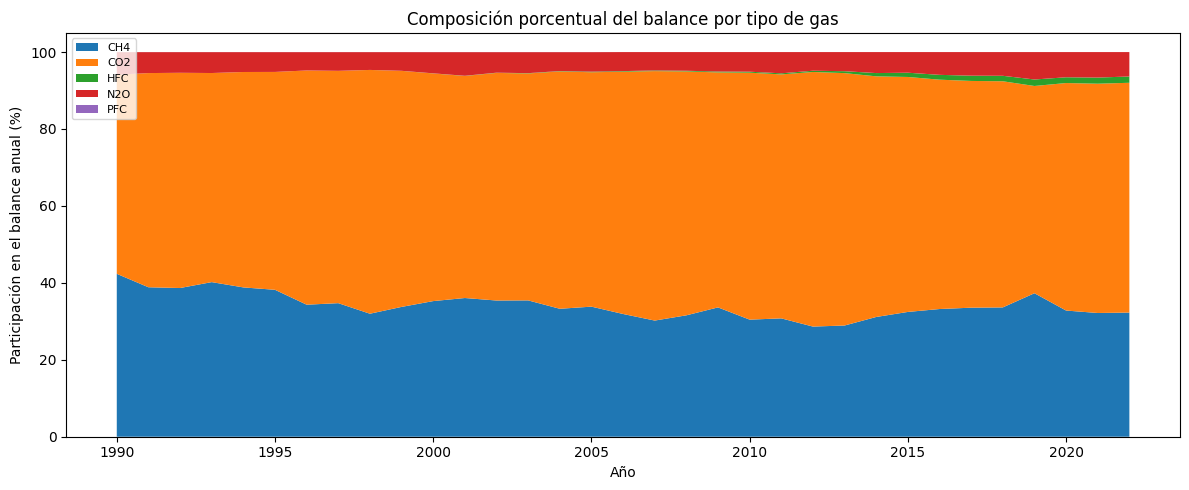

tipo_de_gas,CH4,CO2,HFC,N2O,PFC
año,,,,,
1990,42.4,51.8,0.0,5.9,0.0
2022,32.3,59.7,1.6,6.3,0.0


In [24]:
pivot_gas_año = df.pivot_table(index="año", columns="tipo_de_gas", values=VALOR, aggfunc="sum").fillna(0)
composicion_gas = pivot_gas_año.div(pivot_gas_año.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 5))
plt.stackplot(composicion_gas.index, [composicion_gas[g] for g in composicion_gas.columns],
              labels=composicion_gas.columns)
plt.xlabel("Año")
plt.ylabel("Participación en el balance anual (%)")
plt.title("Composición porcentual del balance por tipo de gas")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

composicion_gas.loc[[1990, 2022]].round(1)

El **CO₂** domina el balance acumulado (60,3 %), seguido por el **CH₄** (33,8 %) y el **N₂O** (5,4 %). Los gases sintéticos pesan muy poco: HFC 0,5 % y PFC prácticamente cero.

La composición cambió con los años. En 1990 el CO₂ representaba el 51,8 % del balance anual y el CH₄ el 42,4 %; en 2022 el CO₂ sube a 59,7 % y el CH₄ baja a 32,3 %. El N₂O se mantiene estable (5,9 % en 1990 y 6,3 % en 2022) y los HFC, que el inventario recién informa desde 1997, llegan a 1,6 % en 2022.

## 6. Actividades y categorías

### 6.1 Qué actividades explican los dos sectores principales


Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra
actividad
Ganadería        2701.09
Tierra           2368.58
Uso de Suelos     830.25

Energía
actividad
Actividades de quema de combustible                                   4669.41
Emisiones fugitivas provenientes de la fabricación de combustibles     753.00


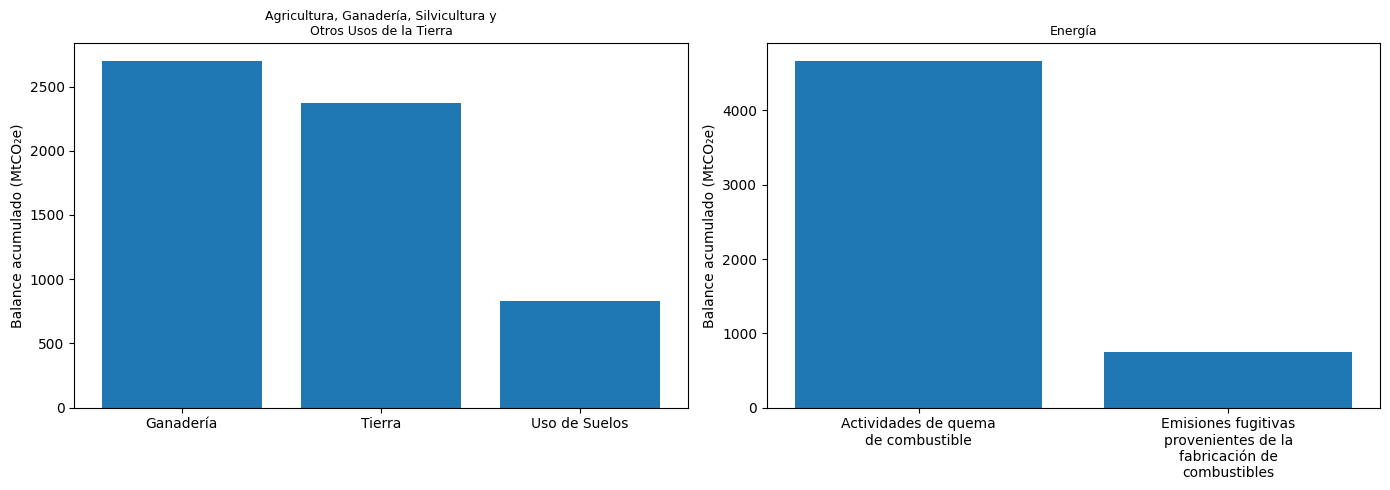

In [25]:
sectores_principales = [
    "Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra",
    "Energía",
]

actividades_por_sector = {
    sector: df[df["sector"] == sector].groupby("actividad")[VALOR].sum().sort_values(ascending=False)
    for sector in sectores_principales
}

for sector, serie in actividades_por_sector.items():
    print(f"\n{sector}\n{serie.round(2).to_string()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sector in zip(axes, sectores_principales):
    datos = actividades_por_sector[sector]
    ax.bar([fill(a, 20) for a in datos.index], datos.values)
    ax.set_title(fill(sector, 40), fontsize=9)
    ax.set_ylabel("Balance acumulado (MtCO₂e)")
plt.tight_layout()
plt.show()

En Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra el peso se reparte entre "Ganadería" (2.701 MtCO₂e), "Tierra" (2.369), que incluye tanto emisiones como remociones, y "Uso de Suelos" (830).

En Energía el peso está mucho más concentrado: "Actividades de quema de combustible" suma 4.669 MtCO₂e, contra 753 de las emisiones fugitivas. Dentro de la quema de combustible, las subactividades más pesadas son "Industrias de la energía" (1.426) y "Transporte" (1.369).

### 6.2 Principales categorías de los últimos años

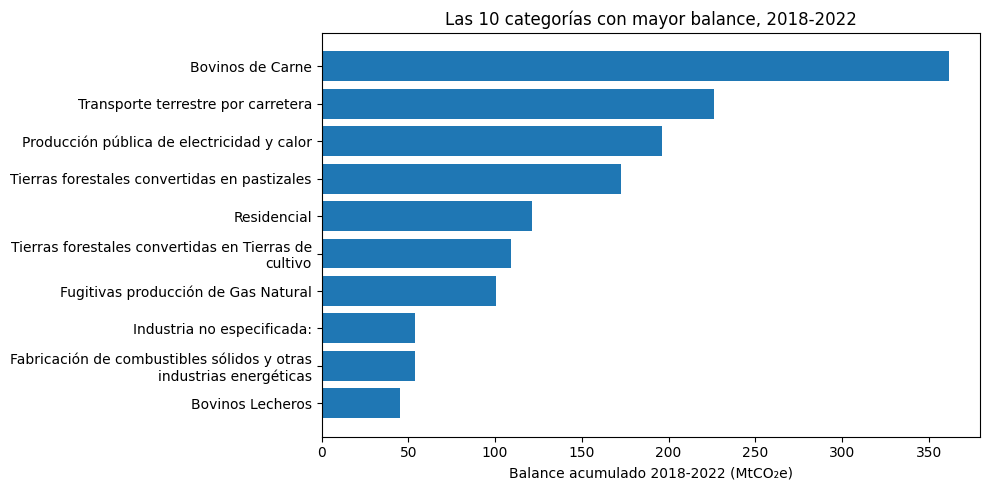

categoria
Bovinos de Carne                                                      361.49
Transporte terrestre por carretera                                    225.97
Producción pública de electricidad y calor                            196.20
Tierras forestales convertidas en pastizales                          172.58
Residencial                                                           121.01
Tierras forestales convertidas en Tierras de cultivo                  109.02
Fugitivas producción de Gas Natural                                   100.72
Industria no especificada:                                             53.84
Fabricación de combustibles sólidos y otras industrias energéticas     53.68
Bovinos Lecheros                                                       45.32
Name: valor_en_toneladas_de_co2e, dtype: float64

In [26]:
top_categorias_recientes = (
    df[df["año"] >= 2018]
    .groupby("categoria")[VALOR]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh([fill(c, 45) for c in top_categorias_recientes.index[::-1]], top_categorias_recientes.values[::-1])
plt.xlabel("Balance acumulado 2018-2022 (MtCO₂e)")
plt.title("Las 10 categorías con mayor balance, 2018-2022")
plt.tight_layout()
plt.show()

top_categorias_recientes.round(2)

En 2018-2022, la categoría individual de mayor aporte es "Bovinos de Carne" (361,5 MtCO₂e), seguida por "Transporte terrestre por carretera" (226,0) y "Producción pública de electricidad y calor" (196,2). En el listado también aparecen dos categorías de cambio de uso de la tierra: "Tierras forestales convertidas en pastizales" y "Tierras forestales convertidas en Tierras de cultivo". "Bovinos de Carne" encabeza además el período completo (2.485,1).

## 7. Conclusiones

Volviendo a la pregunta inicial, esto es lo que muestran los datos:

* **El balance de emisiones creció, pero no de forma pareja.** Pasó de 273,7 MtCO₂e en 1990 a 400,8 en 2022 (46 % más), con un máximo de 450,0 en 2007. Desde 2009 se mueve entre 347,0 y 428,2.
* **Cambió el peso de los sectores.** Energía fue el que más creció y pasó de 37,4 % a 50,0 % del balance anual, y la quema de combustibles explica 4.669 de sus 5.422 MtCO₂e acumulados. Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra sigue siendo el de mayor volumen acumulado, pero bajó de 55,2 % a 38,3 %, y su pico de 2007 se debe sobre todo a los cambios de uso de la tierra.
* **El CO₂ gana peso y el CH₄ lo pierde.** El CO₂ pasó de 51,8 % a 59,7 % del balance anual, y el CH₄ de 42,4 % a 32,3 %.
* **Las remociones crecieron, pero compensan una parte menor.** En 2022 equivalen al 12 % de las emisiones brutas. Los 144 valores negativos son CO₂ de la actividad "Tierra" y se conservaron con su propia etiqueta en `tipo_de_registro`.
* **Desde la gestión ambiental, hay tres focos claros:** la ganadería bovina, la quema de combustibles (en especial transporte y generación eléctrica) y la conversión de tierras forestales a pastizales y a cultivos. Los tres aparecen entre las principales categorías de 2018-2022.

**Para tener en cuenta:** el inventario incorporó detalle con los años (sección 2.3), las comparaciones entre 1990 y 2022 miran solo dos puntos, y las unidades se interpretaron como MtCO₂e (sección 2.4).

## 8. Guardado del dataset limpio

Guardamos el dataset sin duplicados exactos, con los textos normalizados y con la variable `tipo_de_registro`. Es el archivo que carga el notebook 02 para armar el modelo SQL.

In [27]:
archivo = PROCESSED / "emisiones_gei_1990_2022.csv"
df.to_csv(archivo, index=False)

# Control: el balance total debe coincidir con el que se valida en SQL (notebook 02)
assert abs(df[VALOR].sum() - 12398.33) < 0.01
print(f"Guardado en {archivo.relative_to(ROOT)}: {df.shape[0]} filas y {df.shape[1]} columnas")
print(f"Balance total del período: {df[VALOR].sum():,.2f} MtCO₂e")

Guardado en data\processed\emisiones_gei_1990_2022.csv: 7737 filas y 9 columnas
Balance total del período: 12,398.33 MtCO₂e
